## Import the Necessary Libraries

In [20]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2

import numpy as np
import os
import cv2
import matplotlib.pyplot as plt

## Prepare the Dataset

In [21]:
train_datagen = ImageDataGenerator(
    rescale = 1./255,
    zoom_range = 0.2,
    shear_range = 0.2,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    rotation_range = 25,
    horizontal_flip = True,
    fill_mode = 'nearest'
)

valid_datagen = ImageDataGenerator(rescale=1./255)

test_datagen = ImageDataGenerator(rescale=1./255)

In [22]:
train_dataset = train_datagen.flow_from_directory(
    '/kaggle/input/food11-image-dataset/training',
    target_size = (224, 224),
    batch_size = 32,
    class_mode = 'categorical',
    shuffle = True,
)

valid_dataset = valid_datagen.flow_from_directory(
    '/kaggle/input/food11-image-dataset/validation',
    target_size = (224, 224),
    batch_size = 32,
    class_mode = 'categorical',
)

test_dataset = test_datagen.flow_from_directory(
    '/kaggle/input/food11-image-dataset/evaluation',
    target_size = (224, 224),
    batch_size = 32,
    class_mode = 'categorical',
)

Found 9866 images belonging to 11 classes.
Found 3430 images belonging to 11 classes.
Found 3347 images belonging to 11 classes.


## Define the Model

In [23]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(1024, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(11, activation='softmax')(x)

model = tf.keras.Model(inputs=base_model.input, outputs=x)

## Train the Model

In [24]:
learning_rate = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', patience=3, factor=0.3)

model.compile(
    loss = 'categorical_crossentropy',
    optimizer = 'adam',
    metrics = ['accuracy']
)

In [25]:
history = model.fit(train_dataset, validation_data=valid_dataset, epochs=2, callbacks=[learning_rate])

Epoch 1/2
309/309 ━━━━━━━━━━━━━━━━━━━━ 146s 439ms/step - accuracy: 0.4950 - loss: 1.5902 - val_accuracy: 0.7671 - val_loss: 0.7493 - learning_rate: 0.0010
Epoch 2/2
309/309 ━━━━━━━━━━━━━━━━━━━━ 134s 426ms/step - accuracy: 0.7126 - loss: 0.8829 - val_accuracy: 0.7924 - val_loss: 0.6397 - learning_rate: 0.0010


In [26]:
model.save('fic.h5')

## Fine-tune the Model

In [27]:
base_model.trainable = True
model.compile(
    loss = 'categorical_crossentropy',
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-5),
    metrics = ['accuracy']
)

In [28]:
history_tune = model.fit(train_dataset, validation_data=valid_dataset, epochs=2, callbacks=[learning_rate])

Epoch 1/2
309/309 ━━━━━━━━━━━━━━━━━━━━ 196s 505ms/step - accuracy: 0.5840 - loss: 1.2717 - val_accuracy: 0.8020 - val_loss: 0.6410 - learning_rate: 1.0000e-05
Epoch 2/2
309/309 ━━━━━━━━━━━━━━━━━━━━ 136s 430ms/step - accuracy: 0.7207 - loss: 0.8601 - val_accuracy: 0.8195 - val_loss: 0.5909 - learning_rate: 1.0000e-05


In [29]:
model.save('fic_tuned.h5')

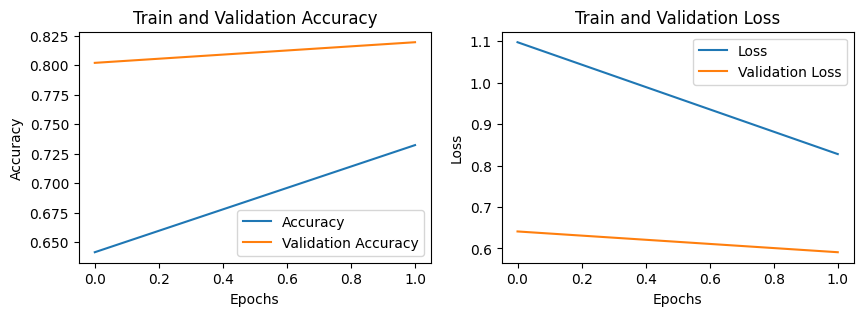

In [30]:
plt.figure(figsize=(10, 3))

plt.subplot(1, 2, 1)
plt.title('Train and Validation Accuracy')
plt.plot(history_tune.history['accuracy'], label='Accuracy')
plt.plot(history_tune.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.title('Train and Validation Loss')
plt.plot(history_tune.history['loss'], label='Loss')
plt.plot(history_tune.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

In [31]:
result_train = model.evaluate(train_dataset)
result_val = model.evaluate(valid_dataset)

print('Train Dataset Accuracy: ', result_train[1])
print('Train Dataset Loss: ', result_train[0])
print('-' * 40)

print('Validation Dataset Accuracy: ', result_val[1])
print('Validation Dataset Loss: ', result_val[0])
print('-' * 40)

309/309 ━━━━━━━━━━━━━━━━━━━━ 120s 390ms/step - accuracy: 0.8123 - loss: 0.5622
108/108 ━━━━━━━━━━━━━━━━━━━━ 13s 118ms/step - accuracy: 0.8140 - loss: 0.5983
Train Dataset Accuracy:  0.8148185610771179
Train Dataset Loss:  0.5672894716262817
----------------------------------------
Validation Dataset Accuracy:  0.8195335268974304
Validation Dataset Loss:  0.5908746123313904
----------------------------------------
